# Random Forest - Top model according to the SCPM of -10.57

In [1]:
%load_ext nb_black

<IPython.core.display.Javascript object>

In [2]:
# Database Reading and Manipulation
import pandas as pd

# Linear Algebra
import numpy as np

# Plotting
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# Model Selection
from sklearn.model_selection import train_test_split
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import RepeatedKFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
from sklearn.model_selection import GridSearchCV

# Modeling
from sklearn.ensemble import RandomForestRegressor

# Metrics
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import r2_score

# Processing
from sklearn.preprocessing import StandardScaler


# Pipeline
from sklearn.pipeline import Pipeline

# Data imputation
from sklearn.impute import SimpleImputer

# Custom modules
## Model selection
from src.cross_validation.blocking_time_series_split import BlockingTimeSeriesSplit

## Function to print scores
from src.utils.print_scores import print_scores

## Function to calculate score regression metrics
from src.utils.score_regression_metrics import score_regression_metrics

## Function to fill the results metric dict
from src.utils.fill_results_dict import fill_results_dict

# Warnings
import warnings

<IPython.core.display.Javascript object>

# Functions and definitions

In [3]:
def get_random_forest_df_importances(scores):
    importances = {}
    importances_with_column = []
    columns = x.columns

    for index, pipeline in enumerate(scores["estimator"]):
        model = pipeline.named_steps["estimator"]
        importances[index] = model.feature_importances_

    for index, importances_vec in importances.items():
        importances_col = pd.DataFrame(
            {col: [c] for col, c in zip(columns, importances_vec)},
            index=[f"Importances - {index}"],
        )
        importances_with_column.append(importances_col)
    df_importances = pd.concat(importances_with_column)

    return df_importances

<IPython.core.display.Javascript object>

In [4]:
SEED = 47
METRICS = (
    "neg_root_mean_squared_error",
    "neg_mean_absolute_error",
    "neg_mean_absolute_percentage_error",
    "r2",
)
METRICS_DICT = {
    "neg_root_mean_squared_error": "RMSE",
    "neg_mean_absolute_error": "MAE",
    "neg_mean_absolute_percentage_error": "MAPE",
    "r2": "R2",
}

<IPython.core.display.Javascript object>

## Defining a dataframe structure to save the results

In [5]:
results_to_save = []

results_dict = {
    "Category": "Local Model",
    "Company": "209",
    "Plant": "S",
    "Features": "Chemical",
    "Data Shape": None,
    "Timesteps": None,
    "Model": "Random Forest",
    "Model Params": None,
    "Scaler": None,
    "Scaler Params": None,
    "Imputer": "Median",
    "Imputer Params": None,
    "Cross Validation": None,
    "Cross Validation Params": np.nan,
    "RMSE Train": np.nan,
    "MAE Train": np.nan,
    "MAPE Train": np.nan,
    "R2 Train": np.nan,
    "RMSE Test": np.nan,
    "MAE Test": np.nan,
    "MAPE Test": np.nan,
    "R2 Test": np.nan,
}

<IPython.core.display.Javascript object>

# Reading the dataset

In [6]:
df = pd.read_csv("../../../../data/processed/209/s.csv")

<IPython.core.display.Javascript object>

## Defining Features

In this set of experiments we keep only chemical and mineralogical features yielded by the same testing method/procedure

In [7]:
df_copy = df.copy().drop(
    [
        "Cement_Type",
        "Blaine",
        "#400",
        "Final setting time",
        "Initial setting time",
        "CS3",
        "CS7",
    ],
    axis=1,
)

<IPython.core.display.Javascript object>

# 1. Decision Tree Regressor

In [8]:
PARAMS = {
    "criterion": "squared_error",
    "n_estimators": 5,
    "max_depth": 3,
    "random_state": SEED,
}

<IPython.core.display.Javascript object>

<h2>1. Dataset: df_no_cs</h2> <br>In this dataset the CS1, CS3  and CS7 variables are not considered. Only Chemical and mineralogical features measured by the same method. For this particular dataset, all chemical features, with the exception of LOI were measured by XRF and XRD methods.

In [9]:
y = df_copy.pop("CS28").values
x = df_copy.drop(["Date"], axis=1)
dates = df["Date"].copy()

<IPython.core.display.Javascript object>

## 1.3. Time Series Split Cross Validation

In [10]:
repeats = 3
n_splits = 5
gap = 0
pipeline = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("estimator", RandomForestRegressor(**PARAMS)),
    ]
)
cv = TimeSeriesSplit(gap=gap, max_train_size=None, n_splits=n_splits, test_size=None)

scores = cross_validate(
    pipeline,
    x,
    y,
    scoring=METRICS,
    cv=cv,
    n_jobs=-1,
    return_train_score=True,
    return_estimator=True,
    return_indices=True,
)
print("Time Series Split:")
print(f"Repeats: {repeats}")
print(f"n_splits: {n_splits}")
print()
print_scores(scores, METRICS, METRICS_DICT)

results_dict_copy = results_dict.copy()
results_dict_copy["Cross Validation"] = "Time Series Split"
results_dict_copy["Cross Validation Params"] = '{"N_Splits": 5, "Repeats": 1, "Gap": 0}'
results_dict_copy["Data Shape"] = x.shape
df_results = fill_results_dict(results_dict_copy, scores)
results_to_save.append(df_results)

Time Series Split:
Repeats: 3
n_splits: 5

******
[TRAIN]
******
RMSE: -0.863 (0.043)
MAE: -0.657 (0.032)
MAPE: -0.016 (0.001)
R2: 0.973 (0.003)


******
[TEST]
******
RMSE: -1.189 (0.285)
MAE: -0.834 (0.127)
MAPE: -0.020 (0.003)
R2: 0.946 (0.021)




<IPython.core.display.Javascript object>

## Plotting the Predictions

In [11]:
# Store predictions for each fold
all_predictions = []

for idx, pipeline in enumerate(scores["estimator"]):
    index_train = scores["indices"]["train"][idx]
    index_test = scores["indices"]["test"][idx]
    index_preds = np.concatenate([index_train, index_test])

    results = pipeline.predict(x.loc[index_preds])

    # Store predictions along with fold information
    fold_predictions = pd.DataFrame(
        {
            "DATE": dates[index_preds],
            "CS28": y[index_preds],
            "CS28_PRED": results,
            "SET": ["TRAIN"] * len(index_train) + ["TEST"] * len(index_test),
            "FOLD": [idx + 1] * len(index_preds),  # Indicate the fold number
        }
    )
    all_predictions.append(fold_predictions)

# Concatenate predictions from all folds
df_pred = pd.concat(all_predictions)
df_pred["DATE"] = pd.to_datetime(df_pred["DATE"])

<IPython.core.display.Javascript object>

In [12]:
df_pred[["DATE", "CS28", "CS28_PRED", "SET"]]

,DATE,CS28,CS28_PRED,SET
0,2021-01-02,34.200001,34.421309,TRAIN
1,2021-01-04,34.700001,34.769063,TRAIN
2,2021-01-04,46.099998,45.292329,TRAIN
3,2021-01-05,45.799999,45.292329,TRAIN
4,2021-01-05,34.599998,34.421309,TRAIN
...,...,...,...,...
1490,2023-07-15,46.500000,44.681523,TEST
1491,2023-07-18,46.500000,44.806174,TEST
1492,2023-07-18,34.400002,34.582850,TEST
1493,2023-07-19,46.099998,44.806174,TEST


<IPython.core.display.Javascript object>

In [13]:
df_copy_copy = df_copy.copy()
df_copy_copy["Date"] = pd.to_datetime(df_copy_copy["Date"])
df_copy_copy["Date"] = df_copy_copy["Date"].dt.tz_localize(None)

df_pred_copy = df_pred.copy()
df_pred_copy["DATE"] = pd.to_datetime(df_pred_copy["DATE"])
df_pred_copy["DATE"] = df_pred_copy["DATE"].dt.tz_localize(None)

df_copy_merge = df_copy_copy.reset_index(drop=True).merge(
    df_pred_copy.reset_index(drop=True), left_index=True, right_index=True, how="inner"
)
df_copy_merge["COMPANY"] = "209_s"
df_copy_merge["PLANT"] = "209_s"

for fold, (train_index, test_index) in enumerate(cv.split(x)):
    df_copy_merge.loc[train_index, "FOLD"] = fold + 1
    df_copy_merge.loc[test_index, "FOLD"] = fold + 1
df_copy_merge["FOLD"] = df_copy_merge["FOLD"].astype(int)
df_copy_merge.to_excel("local_model_random_forest_tsscv_partner_ii.xlsx", index=False)
df_copy_merge.to_csv("local_model_random_forest_tsscv_partner_ii.csv", index=False)

<IPython.core.display.Javascript object>

In [14]:
df_pred

,DATE,CS28,CS28_PRED,SET,FOLD
0,2021-01-02,34.200001,34.421309,TRAIN,1
1,2021-01-04,34.700001,34.769063,TRAIN,1
2,2021-01-04,46.099998,45.292329,TRAIN,1
3,2021-01-05,45.799999,45.292329,TRAIN,1
4,2021-01-05,34.599998,34.421309,TRAIN,1
...,...,...,...,...,...
1490,2023-07-15,46.500000,44.681523,TEST,5
1491,2023-07-18,46.500000,44.806174,TEST,5
1492,2023-07-18,34.400002,34.582850,TEST,5
1493,2023-07-19,46.099998,44.806174,TEST,5


<IPython.core.display.Javascript object>

In [15]:
(df_pred["SET"] == "TEST").sum()

1245

<IPython.core.display.Javascript object>

In [16]:
matplotlib.rc_file_defaults()

<IPython.core.display.Javascript object>

In [17]:
df[["CS28"]].describe().T

,count,mean,std,min,25%,50%,75%,max
CS28,1495.0,40.124488,5.250426,32.299999,34.799999,42.400002,45.099998,48.599998


<IPython.core.display.Javascript object>

In [18]:
# Store predictions for each fold
all_predictions = []

for idx, pipeline in enumerate(scores["estimator"]):
    index_train = scores["indices"]["train"][idx]
    index_test = scores["indices"]["test"][idx]
    index_preds = np.concatenate([index_train, index_test])

    results = pipeline.predict(x.loc[index_preds])

    # Store predictions along with fold information
    fold_predictions = pd.DataFrame(
        {
            "DATE": dates[index_preds],
            "CS28": y[index_preds],
            "CS28_PRED": results,
            "SET": ["TRAIN"] * len(index_train) + ["TEST"] * len(index_test),
            "FOLD": [idx + 1] * len(index_preds),  # Indicate the fold number
            "index_pred": index_preds,
        }
    )
    all_predictions.append(fold_predictions)

# Concatenate predictions from all folds
df_pred = pd.concat(all_predictions)
df_pred["DATE"] = pd.to_datetime(df_pred["DATE"])

<IPython.core.display.Javascript object>

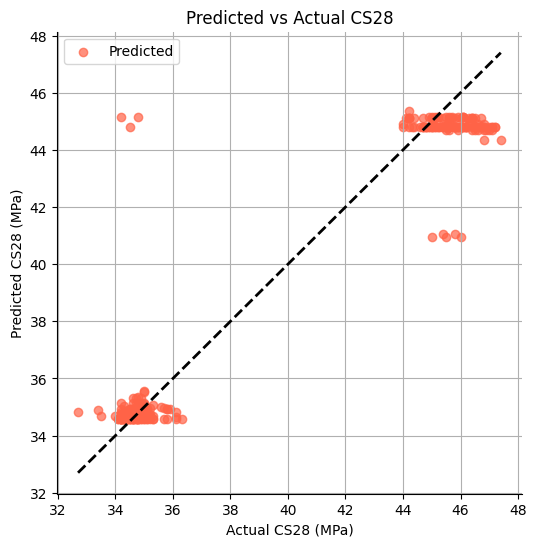

<IPython.core.display.Javascript object>

In [19]:
# Scatter plot of actual vs predicted values
test_data = df_pred[df_pred["SET"] == "TEST"]
test_data = test_data[test_data["FOLD"].isin([5])]


plt.figure(figsize=(6, 6))
plt.scatter(
    test_data["CS28"],
    test_data["CS28_PRED"],
    color="tomato",
    alpha=0.7,
    label="Predicted",
)
plt.plot(
    [test_data["CS28"].min(), test_data["CS28"].max()],
    [test_data["CS28"].min(), test_data["CS28"].max()],
    color="black",
    linestyle="--",
    linewidth=2,
)
plt.xlabel("Actual CS28 (MPa)")
plt.ylabel("Predicted CS28 (MPa)")
plt.title("Predicted vs Actual CS28")
plt.legend()
plt.grid(True)
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.savefig(
    "ecics_partner_ix_plant_s_cm_tiss_last_fold_pred_vs_actual_cs28.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

In [20]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Free CaO,1491.0,1.481321,0.440323,0.700000,1.130000,1.420000,1.770000,2.990000
CaO,1489.0,56.535401,3.747020,43.527000,53.054001,58.021999,60.000999,63.293999
MgO,1489.0,4.966560,0.489584,3.134000,4.647000,4.969940,5.317000,7.173000
Na2O,1489.0,0.202710,0.033811,0.125000,0.179000,0.197000,0.224000,0.491000
Al2O3,1486.0,4.829193,0.623002,3.730000,4.223000,4.773500,5.398000,6.944000
SiO2,1489.0,20.692523,2.124614,16.054001,18.652000,19.694000,22.771999,25.888000
SO3,1489.0,2.744147,0.142467,1.570000,2.669000,2.743000,2.827000,3.265000
K2O,1489.0,0.716730,0.172401,0.351000,0.566000,0.714000,0.868000,1.076000
Fe2O3,1489.0,3.022008,0.176738,2.267000,2.894000,3.032000,3.149000,3.879000
Loss on Ignition,1492.0,6.960268,0.970709,4.160000,6.130000,7.050000,7.812500,8.660000


<IPython.core.display.Javascript object>

In [21]:
df["Final setting time"].describe(percentiles=[.9,.99, 1])


count    1475.000000
mean      205.433220
std        57.717521
min        70.000000
50%       203.000000
90%       240.000000
99%       270.000000
100%     2135.000000
max      2135.000000
Name: Final setting time, dtype: float64

<IPython.core.display.Javascript object>

In [22]:
test_data[
    (test_data["CS28"] >= 34)
    & (test_data["CS28"] <= 36)
    & (test_data["CS28_PRED"] >= 44)
    & (test_data["CS28_PRED"] <= 46)
]

,DATE,CS28,CS28_PRED,SET,FOLD,index_pred
1380,2023-04-25,34.799999,45.163672,TEST,5,1380
1382,2023-04-26,34.200001,45.163672,TEST,5,1382
1387,2023-05-02,34.500000,44.806174,TEST,5,1387


<IPython.core.display.Javascript object>

In [23]:
df_copy.iloc[[1380, 1382, 1387]]

,Date,Free CaO,CaO,MgO,Na2O,Al2O3,SiO2,SO3,K2O,Fe2O3,Loss on Ignition,Insoluble Residue
1380,2023-04-25,1.66,53.777000,4.718,0.177,5.172,22.148001,2.957,0.859,3.134,7.23,2.01
1382,2023-04-26,1.35,53.557999,4.899,0.181,5.262,22.646999,2.712,0.885,3.198,7.06,2.19
1387,2023-05-02,1.69,53.347000,5.305,0.290,4.991,22.420000,2.575,0.874,3.178,7.38,2.91


<IPython.core.display.Javascript object>

In [24]:
df.iloc[[1380, 1382, 1387]]

,Date,Free CaO,CaO,MgO,Na2O,Al2O3,SiO2,SO3,K2O,Fe2O3,Loss on Ignition,Insoluble Residue,Blaine,#400,Initial setting time,Final setting time,CS3,CS7,CS28,Cement_Type
1380,2023-04-25,1.66,53.777000,4.718,0.177,5.172,22.148001,2.957,0.859,3.134,7.23,2.01,5080.0,10.11,171.0,201.0,22.500000,27.799999,34.799999,CP II-Z-32
1382,2023-04-26,1.35,53.557999,4.899,0.181,5.262,22.646999,2.712,0.885,3.198,7.06,2.19,4980.0,9.06,170.0,209.0,22.299999,27.700001,34.200001,CP II-Z-32
1387,2023-05-02,1.69,53.347000,5.305,0.290,4.991,22.420000,2.575,0.874,3.178,7.38,2.91,4980.0,9.86,172.0,205.0,23.799999,27.600000,34.500000,CP II-Z-32


<IPython.core.display.Javascript object>

In [25]:
pipeline.predict(df_copy.iloc[[1380, 1382, 1387]].drop("Date", axis=1))

array([45.16367238, 45.16367238, 44.80617369])

<IPython.core.display.Javascript object>

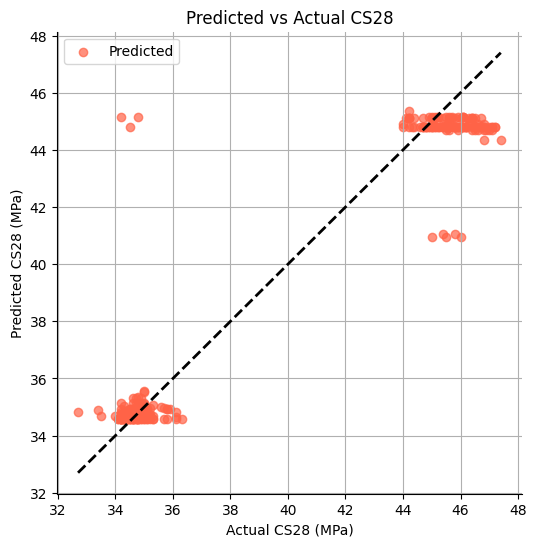

<IPython.core.display.Javascript object>

In [26]:
# Scatter plot of actual vs predicted values
test_data = df_pred[df_pred["SET"] == "TEST"]
test_data = test_data[test_data["FOLD"].isin([5])]
plt.figure(figsize=(6, 6))
plt.scatter(
    test_data["CS28"],
    test_data["CS28_PRED"],
    color="tomato",
    alpha=0.7,
    label="Predicted",
)
plt.plot(
    [test_data["CS28"].min(), test_data["CS28"].max()],
    [test_data["CS28"].min(), test_data["CS28"].max()],
    color="black",
    linestyle="--",
    linewidth=2,
)
plt.xlabel("Actual CS28 (MPa)")
plt.ylabel("Predicted CS28 (MPa)")
plt.title("Predicted vs Actual CS28")
plt.legend()
plt.grid(True)
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.savefig(
    "ecics_partner_ix_plant_s_cm_tiss_last_fold_pred_vs_actual_cs28.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

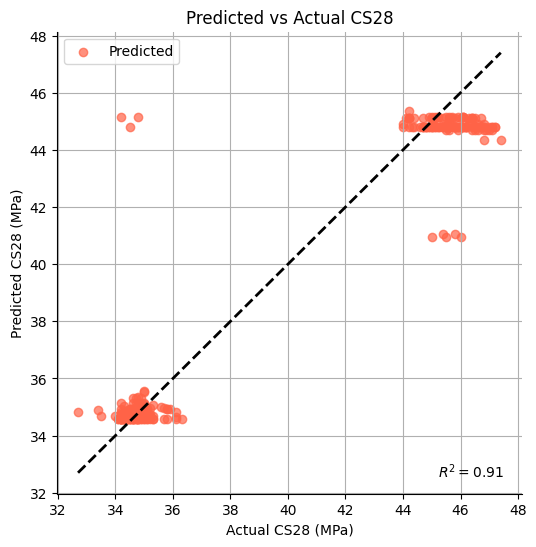

<IPython.core.display.Javascript object>

In [27]:
# Scatter plot of actual vs predicted values
test_data = df_pred[df_pred["SET"] == "TEST"]
test_data = test_data[test_data["FOLD"].isin([5])]
plt.figure(figsize=(6, 6))
plt.scatter(
    test_data["CS28"],
    test_data["CS28_PRED"],
    color="tomato",
    alpha=0.7,
    label="Predicted",
)
plt.plot(
    [test_data["CS28"].min(), test_data["CS28"].max()],
    [test_data["CS28"].min(), test_data["CS28"].max()],
    color="black",
    linestyle="--",
    linewidth=2,
)
plt.xlabel("Actual CS28 (MPa)")
plt.ylabel("Predicted CS28 (MPa)")
plt.title("Predicted vs Actual CS28")
plt.legend()
plt.grid(True)
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

r2 = 0.91
plt.text(
    0.82,
    0.07,
    f"$R^2 = {r2:.2f}$",
    transform=plt.gca().transAxes,
    verticalalignment="top",
)

plt.savefig(
    "ecics_partner_ix_plant_s_cm_tiss_last_fold_pred_vs_actual_cs28.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

In [28]:
from sklearn.metrics import r2_score

test_data = df_pred[df_pred["SET"] == "TEST"]
test_data = test_data[test_data["FOLD"].isin([5])]

r2_score(test_data["CS28"], test_data["CS28_PRED"])

0.9137507906856746

<IPython.core.display.Javascript object>

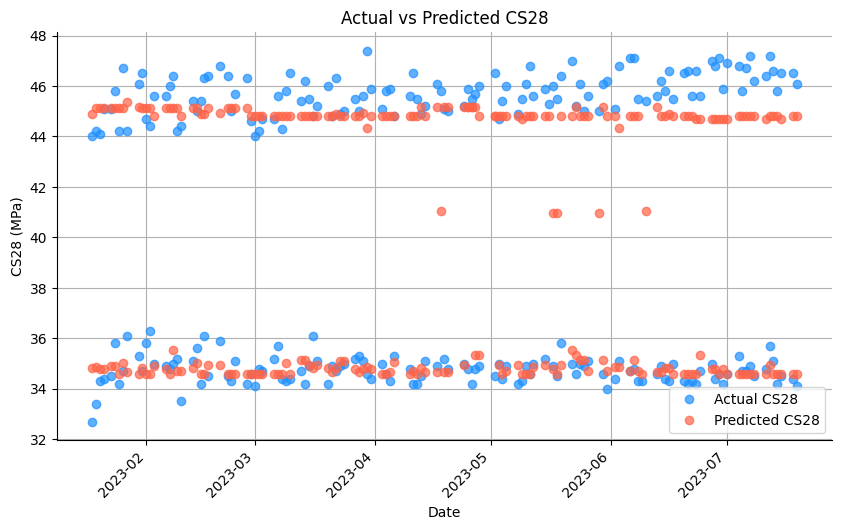

<IPython.core.display.Javascript object>

In [29]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.figure(figsize=(10, 6))
plt.plot(
    test_data["DATE"],
    test_data["CS28"],
    color="dodgerblue",
    alpha=0.7,
    marker="o",
    linestyle="none",
    label="Actual CS28",
)
plt.plot(
    test_data["DATE"],
    test_data["CS28_PRED"],
    color="tomato",
    alpha=0.7,
    marker="o",
    linestyle="none",
    label="Predicted CS28",
)
plt.xlabel("Date")
plt.ylabel("CS28 (MPa)")
plt.title("Actual vs Predicted CS28")
plt.legend()
plt.grid(True)

# Improving x-axis readability
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())  # Set ticks for each month
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))  # Format date as 'YYYY-MM-DD'
plt.gcf().autofmt_xdate(rotation=45)  # Rotate x-axis labels

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.savefig(
    "ecics_partner_ix_plant_s_cm_tiss_last_fold_pred_vs_actual_cs28_over_time.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()


In [30]:
len(test_data), 175 * 5

(249, 875)

<IPython.core.display.Javascript object>

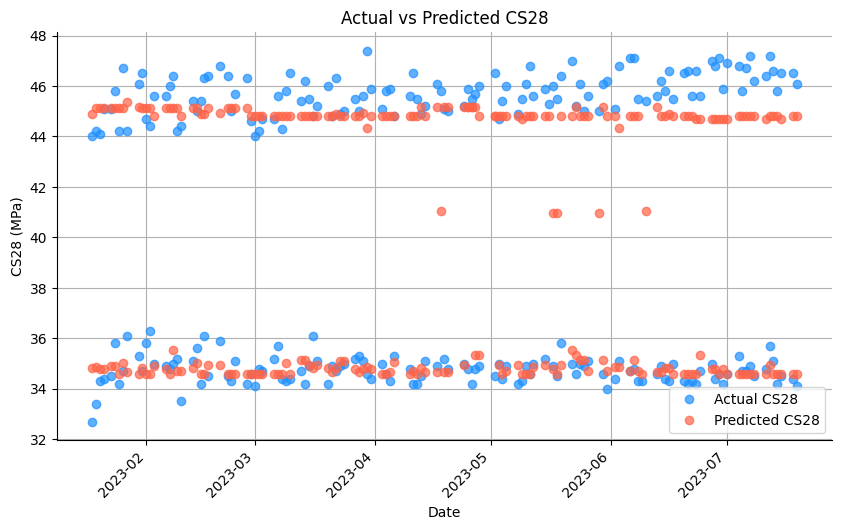

<IPython.core.display.Javascript object>

In [31]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.figure(figsize=(10, 6))
plt.plot(
    test_data["DATE"],
    test_data["CS28"],
    color="dodgerblue",
    alpha=0.7,
    marker="o",
    linestyle="none",
    label="Actual CS28",
)
plt.plot(
    test_data["DATE"],
    test_data["CS28_PRED"],
    color="tomato",
    alpha=0.7,
    marker="o",
    linestyle="none",
    label="Predicted CS28",
)
plt.xlabel("Date")
plt.ylabel("CS28 (MPa)")
plt.title("Actual vs Predicted CS28")
plt.legend()
plt.grid(True)

# Improving x-axis readability
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())  # Set ticks for each month
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))  # Format date as 'YYYY-MM-DD'
plt.gcf().autofmt_xdate(rotation=45)  # Rotate x-axis labels

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.savefig(
    "ecics_partner_ix_plant_s_cm_tiss_last_fold_pred_vs_actual_cs28_over_time.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()


## Assessing Feature Importance

In [32]:
df_importances = get_random_forest_df_importances(scores)

<IPython.core.display.Javascript object>

In [33]:
df_importances

,Free CaO,CaO,MgO,Na2O,Al2O3,SiO2,SO3,K2O,Fe2O3,Loss on Ignition,Insoluble Residue
Importances - 0,0.000000,0.591537,0.003712,0.001469,0.001788,0.198180,0.002205,0.000596,0.001738,0.001874,0.196902
Importances - 1,0.003906,0.000871,0.004221,0.000277,0.000000,0.000459,0.000117,0.000726,0.000890,0.000398,0.988134
Importances - 2,0.003244,0.001838,0.002535,0.000000,0.000000,0.000000,0.000171,0.000254,0.000000,0.000640,0.991319
Importances - 3,0.002778,0.002248,0.000690,0.000000,0.000000,0.000863,0.000196,0.000093,0.000000,0.000631,0.992501
Importances - 4,0.000124,0.002636,0.001033,0.000179,0.000163,0.000000,0.000000,0.001779,0.000000,0.001298,0.992790


<IPython.core.display.Javascript object>

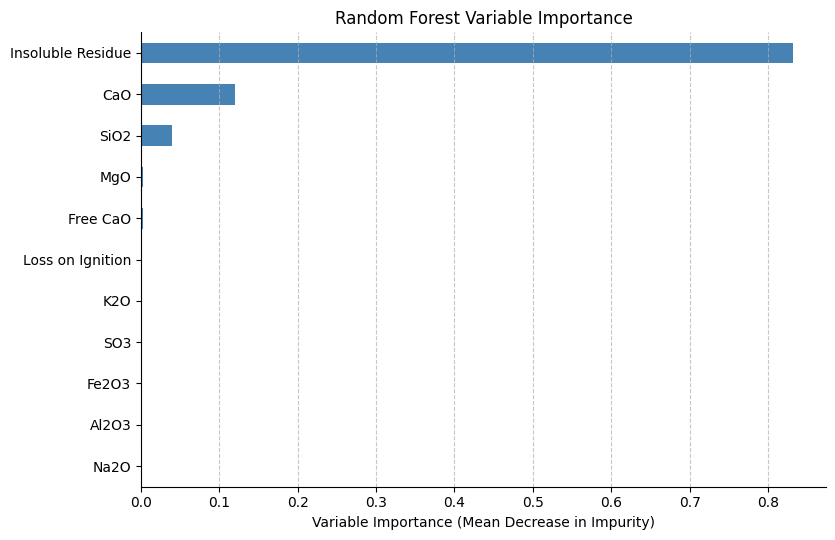

<IPython.core.display.Javascript object>

In [34]:
df_importances.mean(axis=0).sort_values().plot(
    kind="barh", figsize=(10, 5.5), color="steelblue"  # Consider using 'steelblue'
)
plt.title("Random Forest Variable Importance")
plt.xlabel("Variable Importance (Mean Decrease in Impurity)")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.tight_layout()
plt.subplots_adjust(left=0.3)
plt.show()

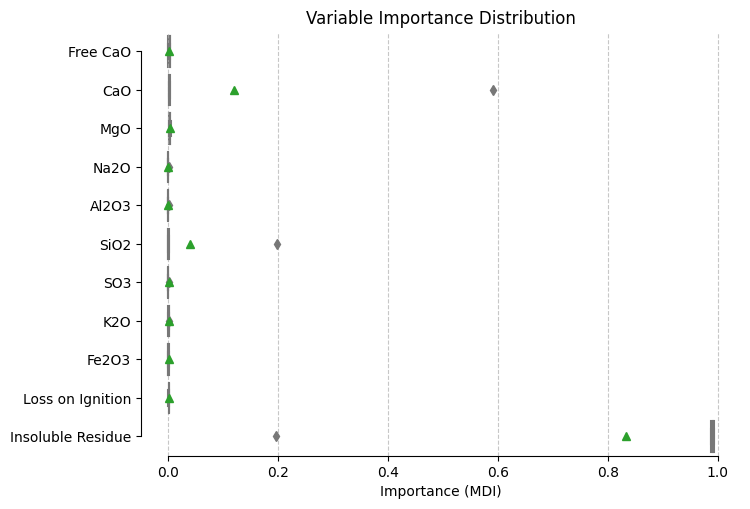

<IPython.core.display.Javascript object>

In [35]:
warnings.filterwarnings("ignore")
plt.figure(figsize=(10, 5.5))
sns.boxplot(data=df_importances, orient="h", color="lightsteelblue", saturation=0.7, showmeans=True)
sns.despine(trim=True, left=False)
plt.xlabel("Importance (MDI)")
plt.title("Variable Importance Distribution")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.subplots_adjust(left=0.3)
plt.show()


In [36]:
# warnings.filterwarnings("ignore")
# plt.figure(figsize=(10, 5.5))
# sns.boxplot(data=df_importances, orient="h", color="lightsteelblue", saturation=1, showmeans=True)
# sns.despine(trim=True, left=False)
# plt.xlabel("Relevance (MDI)")
# plt.title("Variable Relevance Distribution")
# plt.grid(axis='x', linestyle='--', alpha=0.7)
# plt.subplots_adjust(left=0.3)
# plt.show()


<IPython.core.display.Javascript object>

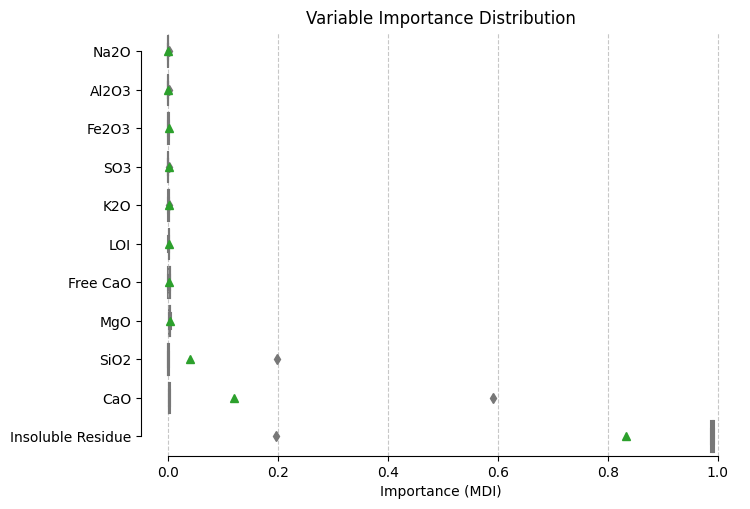

<IPython.core.display.Javascript object>

In [37]:
# Calculate the means of the importance scores
mean_importances = df_importances.mean()

# Sort the features by their mean relevance
sorted_features = mean_importances.sort_values()

# Re-order the DataFrame according to the sorted features
df_importances_sorted = df_importances[sorted_features.index]

# Plot the sorted boxplot
df_importances_sorted = df_importances_sorted.rename(
    columns={"Loss on Ignition": "LOI"}
)

plt.figure(figsize=(10, 5.5))
sns.boxplot(
    data=df_importances_sorted,
    orient="h",
    color="lightsteelblue",
    saturation=1,
    showmeans=True,
)
sns.despine(trim=True, left=False)
plt.xlabel("Importance (MDI)")
plt.title("Variable Importance Distribution")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.subplots_adjust(left=0.3)
plt.savefig(
    "ecics_cm_partner_ix_plant_s_tiss_random_forest_scpm_best_dist_var_relevance.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

In [38]:
print("Default font family:", matplotlib.rcParams["font.family"])
print("Default sans-serif fonts:", matplotlib.rcParams["font.sans-serif"])
print("Default font size:", matplotlib.rcParams["font.size"])
print("Default font weight:", matplotlib.rcParams["font.weight"])

Default font family: ['sans-serif']
Default sans-serif fonts: ['DejaVu Sans', 'Bitstream Vera Sans', 'Computer Modern Sans Serif', 'Lucida Grande', 'Verdana', 'Geneva', 'Lucid', 'Arial', 'Helvetica', 'Avant Garde', 'sans-serif']
Default font size: 10.0
Default font weight: normal


<IPython.core.display.Javascript object>

In [39]:
plt.get_backend()

'module://matplotlib_inline.backend_inline'

<IPython.core.display.Javascript object>

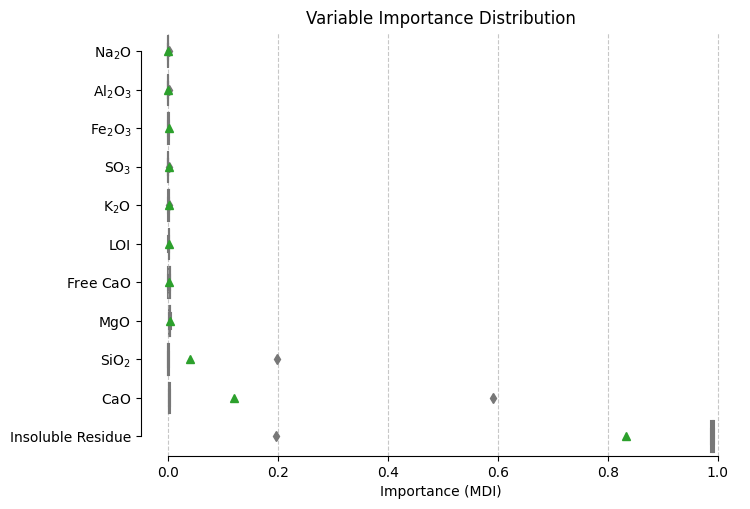

<IPython.core.display.Javascript object>

In [40]:
# Backup the original backend
original_backend = plt.get_backend()

# Use Matplotlib's default backend
# plt.switch_backend("agg")  # or any backend you prefer

# Update font settings to default
plt.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["DejaVu Sans"],
        "font.size": 10,
        "text.usetex": False,  # Use MathText, not LaTeX
    }
)

# plt.rcParams.update(
#     {
#         "mathtext.fontset": "custom",
#         "mathtext.rm": "DejaVu Sans",
#         "mathtext.it": "DejaVu Sans:italic",
#         "mathtext.bf": "DejaVu Sans:bold",
#     }
# )


# Convert chemical formulas using MathText syntax
df_importances_sorted_plot = df_importances_sorted.rename(
    columns={
        "K2O": r"$\mathrm{K_2O}$",
        "Free CaO": r"Free $\mathrm{CaO}$",
        "Total C2S": r"Total $\mathrm{C_2S}$",
        "Na2O": r"$\mathrm{Na_2O}$",
        "CaO": r"$\mathrm{CaO}$",
        "SiO2": r"$\mathrm{SiO_2}$",
        "MgO": r"$\mathrm{MgO}$",
        "Fe2O3": r"$\mathrm{Fe_2O_3}$",
        "Al2O3": r"$\mathrm{Al_2O_3}$",
        "Total C3S": r"Total $\mathrm{C_3S}$",
        "C3A": r"$\mathrm{C_3A}$",
        "C4AF": r"$\mathrm{C_4AF}$",
        "LOI": "LOI",
        "SO3": r"$\mathrm{SO_3}$",
    }
)

plt.figure(figsize=(10, 5.5))
sns.boxplot(
    data=df_importances_sorted_plot,
    orient="h",
    color="lightsteelblue",
    saturation=1,
    showmeans=True,
)
sns.despine(trim=True, left=False)
plt.xlabel("Importance (MDI)")
plt.title("Variable Importance Distribution")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.subplots_adjust(left=0.3)
plt.savefig(
    "ecics_cm_partner_ix_plant_s_tiss_random_forest_scpm_best_dist_var_relevance.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


# Step 3: Reset all rcParams to their default values
matplotlib.rcParams.update(matplotlib.rcParamsDefault)
plt.rcdefaults()

# Switch back to the original backend
plt.switch_backend(original_backend)

In [41]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# original_backend = plt.get_backend()

# # Switch to PGF backend to use XeLaTeX
# plt.switch_backend("pgf")

# # Update Matplotlib rcParams
# plt.rcParams.update(
#     {
#         "pgf.texsystem": "xelatex",
#         "font.family": "sans-serif",
#         "font.sans-serif": ["DejaVu Sans"],
#         "font.size": 10,
#         "font.weight": "black",
#         "axes.labelweight": "black",
#         "axes.linewidth": 1.0,
#         "xtick.labelsize": 10,
#         "ytick.labelsize": 10,
#         "text.usetex": True,
#         "pgf.preamble": r"""
#     \usepackage{fontspec}
#     \setmainfont{DejaVu Sans}[
#         UprightFont = *-Book,
#         BoldFont = *-Bold,
#     ]
#     \usepackage{mhchem}
#     \renewcommand{\seriesdefault}{\bfdefault}
#     \bfseries
#     """,
#     }
# )

# # Your plotting code
# df_importances_sorted_plot = df_importances_sorted.rename(
#     columns={
#         "K2O": r"$\ce{K2O}$",
#         "Free CaO": r"Free $\ce{CaO}$ ",
#         "Total C2S": r"Total $\ce{C2S}$",
#         "Na2O": r"$\ce{Na2O}$",
#         "CaO": r"$\ce{CaO}$",
#         "SiO2": r"$\ce{SiO2}$",
#         "MgO": r"$\ce{MgO}$",
#         "Fe2O3": r"$\ce{Fe2O3}$",
#         "Al2O3": r"$\ce{Al2O3}$",
#         "Total C3S": r"Total $\ce{C3S}$",
#         "C3A": r"$\ce{C3A}$",
#         "C4AF": r"$\ce{C4AF}$",
#         "LOI": "LOI",
#         "SO3": r"$\ce{SO3}$",
#     }
# )

# plt.figure(figsize=(10, 5.5))
# sns.boxplot(
#     data=df_importances_sorted_plot,
#     orient="h",
#     color="lightsteelblue",
#     saturation=1,
#     showmeans=True,
# )
# sns.despine(trim=True, left=False)
# plt.xlabel("Relevance (MDI)")
# plt.title("Variable Relevance Distribution")
# plt.grid(axis="x", linestyle="--", alpha=0.7)
# plt.subplots_adjust(left=0.3)
# plt.savefig(
#     "final_plot_with_xelatex.png",
#     dpi=300,
#     bbox_inches="tight",
# )


# # Step 3: Reset all rcParams to their default values
# plt.rcdefaults()

# # Switch back to the original backend
# plt.switch_backend(original_backend)

# # Now you can display the plot or continue plotting with the original backend
# plt.show()

<IPython.core.display.Javascript object>

In [42]:
df_importances

,Free CaO,CaO,MgO,Na2O,Al2O3,SiO2,SO3,K2O,Fe2O3,Loss on Ignition,Insoluble Residue
Importances - 0,0.000000,0.591537,0.003712,0.001469,0.001788,0.198180,0.002205,0.000596,0.001738,0.001874,0.196902
Importances - 1,0.003906,0.000871,0.004221,0.000277,0.000000,0.000459,0.000117,0.000726,0.000890,0.000398,0.988134
Importances - 2,0.003244,0.001838,0.002535,0.000000,0.000000,0.000000,0.000171,0.000254,0.000000,0.000640,0.991319
Importances - 3,0.002778,0.002248,0.000690,0.000000,0.000000,0.000863,0.000196,0.000093,0.000000,0.000631,0.992501
Importances - 4,0.000124,0.002636,0.001033,0.000179,0.000163,0.000000,0.000000,0.001779,0.000000,0.001298,0.992790


<IPython.core.display.Javascript object>

In [43]:
df_importances.describe().T

,count,mean,std,min,25%,50%,75%,max
Free CaO,5.0,0.002010,0.001824,0.000000,0.000124,0.002778,0.003244,0.003906
CaO,5.0,0.119826,0.263695,0.000871,0.001838,0.002248,0.002636,0.591537
MgO,5.0,0.002438,0.001569,0.000690,0.001033,0.002535,0.003712,0.004221
Na2O,5.0,0.000385,0.000617,0.000000,0.000000,0.000179,0.000277,0.001469
Al2O3,5.0,0.000390,0.000785,0.000000,0.000000,0.000000,0.000163,0.001788
SiO2,5.0,0.039901,0.088482,0.000000,0.000000,0.000459,0.000863,0.198180
SO3,5.0,0.000538,0.000935,0.000000,0.000117,0.000171,0.000196,0.002205
K2O,5.0,0.000689,0.000660,0.000093,0.000254,0.000596,0.000726,0.001779
Fe2O3,5.0,0.000526,0.000780,0.000000,0.000000,0.000000,0.000890,0.001738
Loss on Ignition,5.0,0.000968,0.000608,0.000398,0.000631,0.000640,0.001298,0.001874


<IPython.core.display.Javascript object>

In [44]:
df_importances.mean(axis=0)

Free CaO             0.002010
CaO                  0.119826
MgO                  0.002438
Na2O                 0.000385
Al2O3                0.000390
SiO2                 0.039901
SO3                  0.000538
K2O                  0.000689
Fe2O3                0.000526
Loss on Ignition     0.000968
Insoluble Residue    0.832329
dtype: float64

<IPython.core.display.Javascript object>

In [45]:
df_importances.std(axis=0)

Free CaO             0.001824
CaO                  0.263695
MgO                  0.001569
Na2O                 0.000617
Al2O3                0.000785
SiO2                 0.088482
SO3                  0.000935
K2O                  0.000660
Fe2O3                0.000780
Loss on Ignition     0.000608
Insoluble Residue    0.355219
dtype: float64

<IPython.core.display.Javascript object>

In [46]:
df_importances.std(axis=0, ddof=0)

Free CaO             0.001631
CaO                  0.235856
MgO                  0.001403
Na2O                 0.000552
Al2O3                0.000702
SiO2                 0.079140
SO3                  0.000836
K2O                  0.000590
Fe2O3                0.000697
Loss on Ignition     0.000543
Insoluble Residue    0.317718
dtype: float64

<IPython.core.display.Javascript object>

In [47]:
df_copy.nunique()

Date                  751
Free CaO              184
CaO                  1339
MgO                  1007
Na2O                  167
Al2O3                 874
SiO2                 1207
SO3                   513
K2O                   572
Fe2O3                 602
Loss on Ignition      341
Insoluble Residue     570
dtype: int64

<IPython.core.display.Javascript object>

In [48]:
pipeline.named_steps

{'imputer': SimpleImputer(strategy='median'),
 'estimator': RandomForestRegressor(max_depth=3, n_estimators=5, random_state=47)}

<IPython.core.display.Javascript object>

In [49]:
from sklearn.inspection import permutation_importance

<IPython.core.display.Javascript object>

In [50]:
# Initialize lists to store importance results
mdi_importances = []
perm_importances = []

# Compute feature importances
for i, (train_idx, test_idx) in enumerate(cv.split(x, y)):
    pipeline.fit(x.iloc[train_idx], y[train_idx])

    # Extract the trained model
    model = pipeline.named_steps["estimator"]
    imputer = pipeline.named_steps["imputer"]
    # Compute MDI importance
    mdi_importances.append(model.feature_importances_)

    # Compute permutation importance
    result = permutation_importance(
        model,
        imputer.transform(x.iloc[test_idx]),
        y[test_idx],
        n_repeats=10,
        random_state=SEED,
        n_jobs=-1,
        # scoring="neg_mean_squared_error",
        scoring="r2",
    )
    perm_importances.append(result.importances_mean)

<IPython.core.display.Javascript object>

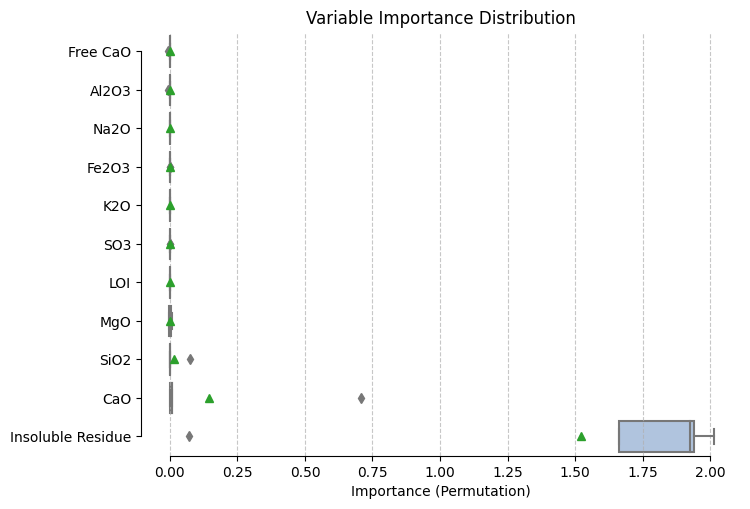

<IPython.core.display.Javascript object>

In [51]:
# Convert lists to DataFrames
mdi_importances_df = pd.DataFrame(mdi_importances, columns=x.columns)
perm_importances_df = pd.DataFrame(perm_importances, columns=x.columns)


# Calculate the mean importance for each feature
mean_importances = perm_importances_df.mean().sort_values()

# Reorder the DataFrame columns based on mean importance
perm_importances_df = perm_importances_df[mean_importances.index]

perm_importances_df = perm_importances_df.rename(columns={"Loss on Ignition": "LOI"})


plt.figure(figsize=(10, 5.5))
sns.boxplot(
    data=perm_importances_df,
    orient="h",
    color="lightsteelblue",
    saturation=1,
    showmeans=True,
)
sns.despine(trim=True, left=False)
plt.xlabel("Importance (Permutation)")
plt.title("Variable Importance Distribution")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.subplots_adjust(left=0.3)
plt.savefig(
    "ecics_cm_partner_ix_plant_s_tiss_random_forest_scpm_best_dist_var_perm_relevance.png",
    dpi=300,
    bbox_inches="tight",
)

# # Step 3: Reset all rcParams to their default values
plt.rcdefaults()

plt.show()

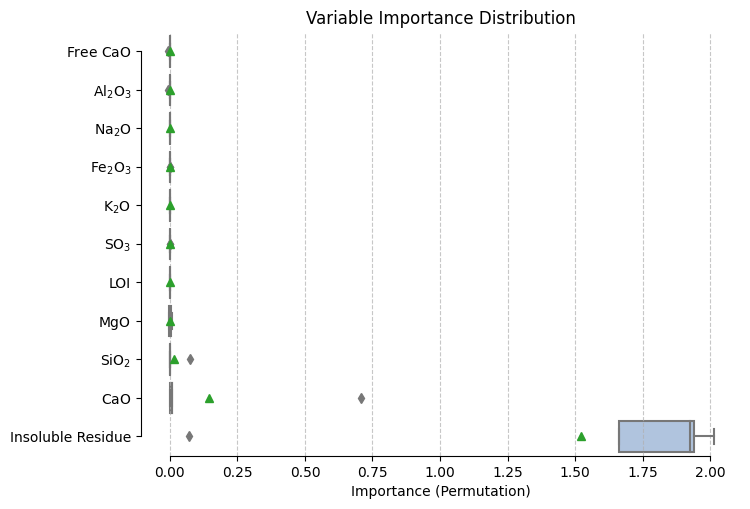

<IPython.core.display.Javascript object>

In [52]:
# Backup the original backend
original_backend = plt.get_backend()

# Update font settings to default
plt.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["DejaVu Sans"],
        "font.size": 10,
        "text.usetex": False,  # Use MathText, not LaTeX
    }
)

# Convert chemical formulas using MathText syntax
perm_importances_df_plot = perm_importances_df.rename(
    columns={
        "K2O": r"$\mathrm{K_2O}$",
        "Free CaO": r"Free $\mathrm{CaO}$",
        "Total C2S": r"Total $\mathrm{C_2S}$",
        "Na2O": r"$\mathrm{Na_2O}$",
        "CaO": r"$\mathrm{CaO}$",
        "SiO2": r"$\mathrm{SiO_2}$",
        "MgO": r"$\mathrm{MgO}$",
        "Fe2O3": r"$\mathrm{Fe_2O_3}$",
        "Al2O3": r"$\mathrm{Al_2O_3}$",
        "Total C3S": r"Total $\mathrm{C_3S}$",
        "C3A": r"$\mathrm{C_3A}$",
        "C4AF": r"$\mathrm{C_4AF}$",
        "LOI": "LOI",
        "SO3": r"$\mathrm{SO_3}$",
    }
)

plt.figure(figsize=(10, 5.5))
sns.boxplot(
    data=perm_importances_df_plot,
    orient="h",
    color="lightsteelblue",
    saturation=1,
    showmeans=True,
)
sns.despine(trim=True, left=False)
plt.xlabel("Importance (Permutation)")
plt.title("Variable Importance Distribution")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.subplots_adjust(left=0.3)
plt.savefig(
    "ecics_cm_partner_ix_plant_s_tiss_random_forest_scpm_best_dist_var_perm_relevance.png",
    dpi=300,
    bbox_inches="tight",
)


# Step 3: Reset all rcParams to their default values
matplotlib.rcParams.update(matplotlib.rcParamsDefault)
plt.rcdefaults()

# Switch back to the original backend
plt.switch_backend(original_backend)

plt.show()

In [53]:
perm_importances_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Free CaO,5.0,-0.001229,0.002748,-0.006144,0.000000,0.000000,0.000000,0.000000
Al2O3,5.0,-0.001169,0.002613,-0.005844,0.000000,0.000000,0.000000,0.000000
Na2O,5.0,-0.000278,0.000318,-0.000773,-0.000345,-0.000272,0.000000,0.000000
Fe2O3,5.0,0.000076,0.000680,-0.000762,0.000000,0.000000,0.000000,0.001140
K2O,5.0,0.000085,0.000635,-0.000528,-0.000450,0.000053,0.000316,0.001033
SO3,5.0,0.000136,0.000663,-0.000589,0.000000,0.000000,0.000043,0.001225
LOI,5.0,0.000376,0.001022,-0.000804,-0.000221,0.000011,0.001416,0.001477
MgO,5.0,0.000787,0.003914,-0.003731,-0.002271,0.001052,0.002905,0.005979
SiO2,5.0,0.015281,0.033674,-0.000178,0.000000,0.000000,0.001070,0.075513
CaO,5.0,0.144000,0.314480,-0.000536,-0.000167,0.006947,0.007236,0.706520


<IPython.core.display.Javascript object>

In [54]:
perm_importances_df

,Free CaO,Al2O3,Na2O,Fe2O3,K2O,SO3,LOI,MgO,SiO2,CaO,Insoluble Residue
0,0.000000,-0.005844,-0.000773,0.001140,-0.000528,-0.000589,0.001416,0.005979,0.075513,0.706520,0.068917
1,0.000000,0.000000,-0.000345,-0.000762,0.000053,0.000043,-0.000221,0.002905,0.001070,-0.000167,2.013452
2,0.000000,0.000000,0.000000,0.000000,0.000316,0.000000,0.001477,-0.002271,0.000000,-0.000536,1.939497
3,-0.006144,0.000000,0.000000,0.000000,0.001033,0.001225,-0.000804,0.001052,-0.000178,0.007236,1.925364
4,0.000000,0.000000,-0.000272,0.000000,-0.000450,0.000000,0.000011,-0.003731,0.000000,0.006947,1.662868


<IPython.core.display.Javascript object>

In [55]:
perm_importances_df.mean(axis=0)

Free CaO            -0.001229
Al2O3               -0.001169
Na2O                -0.000278
Fe2O3                0.000076
K2O                  0.000085
SO3                  0.000136
LOI                  0.000376
MgO                  0.000787
SiO2                 0.015281
CaO                  0.144000
Insoluble Residue    1.522020
dtype: float64

<IPython.core.display.Javascript object>

In [56]:
perm_importances_df.std(axis=0, ddof=0)

Free CaO             0.002458
Al2O3                0.002337
Na2O                 0.000284
Fe2O3                0.000608
K2O                  0.000568
SO3                  0.000593
LOI                  0.000914
MgO                  0.003501
SiO2                 0.030119
CaO                  0.281280
Insoluble Residue    0.736183
dtype: float64

<IPython.core.display.Javascript object>

In [57]:
# fig, ax = plt.subplots(figsize=(12, 8))
# ax.barh(importances_df["Feature"], importances_df["Permutation Importance Mean"], xerr=importances_df["Permutation Importance Std"], color="salmon", alpha=0.7, label="Permutation Importance")
# ax.set_title("Feature Importance: MDI vs Permutation with Standard Deviation")
# ax.set_xlabel("Importance Score")
# ax.legend()
# plt.tight_layout()
# plt.show()

<IPython.core.display.Javascript object>